##Chapter 4 - Spam Detection of Chicago Yelp Reviews

###Part 1: EDA and Baseline Models

This notebook demonstrates the problem outlined in chapter 5, which applies machine learning models to the YelpChi dataset, a collection of labeled reviews from Chicago restaurants.

In part 1, we perform data exploration and apply baseline models. This notebook comprises 3 main parts:

1. **Data Preparation and Exploration**: The code begins by loading and preparing the dataset, which includes features and labels. It also generates adjacency lists for graph data. Initial data exploration is conducted through histograms to visualize feature distributions. The dataset is split into training and testing sets. Then code checks for class balance in the training data are done.

2. **Model Training and Evaluation**: Three baseline models—logistic regression, XGBoost, and a multi-layer perceptron (MLP)—are trained on the training data. The code calculates and displays key performance metrics, such as ROC AUC, F1-score, precision, and recall, for each model.

3. ROC Curve Visualization: To visually compare the models' classification performance, ROC curves are plotted for each model, providing a clear understanding of their discriminative abilities.

In [5]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


In [6]:
import torch
import pickle
import random as rd
import numpy as np
import scipy.sparse as sp
from scipy.io import loadmat
import copy as cp
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize



sns.set(style="whitegrid")

from sklearn.metrics import f1_score, accuracy_score, recall_score, roc_auc_score, average_precision_score
from collections import defaultdict


def sparse_to_adjlist(sp_matrix, filename):
	"""
	Transfer sparse matrix to adjacency list
	:param sp_matrix: the sparse matrix
	:param filename: the filename of adjlist
	"""
	# add self loop
	homo_adj = sp_matrix + sp.eye(sp_matrix.shape[0])
	# create adj_list
	adj_lists = defaultdict(set)
	edges = homo_adj.nonzero()
	for index, node in enumerate(edges[0]):
		adj_lists[node].add(edges[1][index])
		adj_lists[edges[1][index]].add(node)
	with open(filename, 'wb') as file:
		pickle.dump(adj_lists, file)
	file.close()

Note on data: The data files can be found in the repository under the chapter 5 directory. In the colab environment, these files can be uploaded to your folder of choice. Once the folder is chosen, adjust the 'prefix' variables accordingly.

When the file is uploaded, restart the instance.

Often this cell must be run 2 or 3 times for it to work.

##Load and process the dataset.

For this problem, the dataset can be found in the repo in a zipped file. Upload this file into the local directory, and copy the path into the cell below. If uploaded into the top folder, the path below should suffice.

In [7]:
!apt-get install git-lfs -y
!git lfs install
!git clone https://github.com/keitabroadwater/gnns_in_action.git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  git-lfs
0 upgraded, 1 newly installed, 0 to remove and 33 not upgraded.
Need to get 3,908 kB of archives.
After this operation, 11.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 git-lfs amd64 3.4.1-1ubuntu0.4 [3,908 kB]
Fetched 3,908 kB in 24s (163 kB/s)
Selecting previously unselected package git-lfs.
(Reading database ... 127332 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.4.1-1ubuntu0.4_amd64.deb ...
Unpacking git-lfs (3.4.1-1ubuntu0.4) ...
Setting up git-lfs (3.4.1-1ubuntu0.4) ...
Processing triggers for man-db (2.12.0-4build2) ...
Git LFS initialized.
Cloning into 'gnns_in_action'...
remote: Enumerating objects: 864, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 864 (delta 2

In [8]:
%cd /content/gnns_in_action/chapter_4/data
!git lfs pull

/content/gnns_in_action/chapter_4/data


In [9]:
# Note, when uploading your file to colab, you may need to restart the instance for this cell to work.
#!unzip '/content/YelpChi.zip'
!unzip -o YelpChi.zip -d /content/

Archive:  YelpChi.zip
  inflating: /content/yelp_homo_adjlists.pickle  
  inflating: /content/yelp_rsr_adjlists.pickle  
  inflating: /content/yelp_rtr_adjlists.pickle  
  inflating: /content/yelp_rur_adjlists.pickle  
  inflating: /content/YelpChi.mat    
  inflating: /content/__MACOSX/._YelpChi.mat  


In [10]:
prefix = '/content/'

data_file = loadmat('/content/YelpChi.mat')


labels = data_file['label'].flatten()
features = data_file['features'].todense().A

yelp_homo = data_file['homo'] #C
sparse_to_adjlist(yelp_homo, prefix + 'yelp_homo_adjlists.pickle') #C


# load the preprocessed adj_lists
with open(prefix + 'yelp_homo_adjlists.pickle', 'rb') as file:
    homogenous = pickle.load(file)
file.close()


In [11]:
type(features)

numpy.ndarray

###I. Data Exploration

EDA is performed on the dataset, which consists of 32 features

In [12]:
# shape of feature dataset
print(f'number of entries = {features.shape[0]}, number of features = {features.shape[1]}')

number of entries = 45954, number of features = 32


In [13]:
# number of classes and percentage attributed
print(f'number of classes  = {np.unique(labels)}')
print(f'percentage false = {100*labels.sum()/len(labels):.2f}%')

# low percentage of false shows a high class imbalance

number of classes  = [0 1]
percentage false = 14.53%


In [14]:
#Note current data is float64 and int64. Both need to be translated into torch tensors when using pytorch geometric
print(f'features dtype = {features.dtype}, \n' +
      f'label dtype = {labels.dtype}')


features dtype = float64, 
label dtype = int64


In [15]:
features.shape

(45954, 32)

In [16]:
feature_names = ['Rank', 'RD', 'EXT', 'DEV', 'ETF', 'ISR', 'PCW', 'PC', 'L', 'PP1',\
                 'RES', 'SW', 'OW', 'DL_u', 'DL_b', 'MNR_user', 'PR_user',\
                 'NR_user', 'avgRD_user', 'WRD_user', 'BST_user', 'ERD_user',\
                 'ETG_user', 'RL_user', 'MNR_prod', 'PR_prod', 'NR_prod', \
                 'avgRD_prod', 'WRD_prod', 'ERD_prod', 'ETG_prod', 'RL_prod']

In [17]:
feature_names_short_desc_all = ['Rank\nRank order among all the reviews of product',
'RD\nAbsolute rating deviation',
'EXT\nExtremity of rating',
'DEV\nThresholded rating deviation',
'ETF\nEarly time frame',
'ISR\nIs review user’s sole review',
'PCW\nPercentage of ALL-capitals words',
'PC\nPercentage of capital letters',
'L\nReview length in words',
'PP1\nRatio of 1st person pronouns',
'RES\nRatio of sentences containing ‘!’',
'SW\nRatio of subjective words',
'OW\nRatio of objective words',
'DL_u\nLength based on uni-grams',
'DL_b\nLength based on bi-grams',
'MNR_user\nMax # of reviews in a day',
'PR_user\nRatio of positive reviews',
'NR_user\nRatio of negative reviews',
'avgRD_user\nAverage rating deviation',
'WRD_user\nWeighted rating deviation',
'BST_user\nBurstiness of reviews',
'ERD_user\nEntropy of rating distribution',
'ETG_user\nEntropy of temporal gaps ∆t’s',
'RL_user\nAvg review length in # of words',
'MNR_prod\nMax # of reviews written in a day',
'PR_prod\nRatio of positive reviews',
'NR_prod\nRatio of negative reviews',
'avgRD_prod\nAverage rating deviation',
'WRD_prod\nWeighted rating deviation',
'ERD_prod\nEntropy of rating distribution',
'ETG_prod\nEntropy of temporal gaps ∆t’s',
'RL_prod\nAvg review length in # of words',]

In [18]:
feature_names_short_desc_review = ['Rank\nRank order among all the reviews of product',
'RD\nAbsolute rating deviation',
'EXT\nExtremity of rating',
'DEV\nThresholded rating deviation',
'ETF\nEarly time frame',
'ISR\nIs review user’s sole review',
'PCW\nPercentage of ALL-capitals words',
'PC\nPercentage of capital letters',
'L\nReview length in words',
'PP1\nRatio of 1st person pronouns',
'RES\nRatio of sentences containing ‘!’',
'SW\nRatio of subjective words',
'OW\nRatio of objective words',
'DL_u\nLength based on uni-grams',
'DL_b\nLength based on bi-grams',]

In [19]:
feature_names_short_desc_user = [
'MNR_user\nMax # of reviews in a day',
'PR_user\nRatio of positive reviews',
'NR_user\nRatio of negative reviews',
'avgRD_user\nAverage rating deviation',
'WRD_user\nWeighted rating deviation',
'BST_user\nBurstiness of reviews',
'ERD_user\nEntropy of rating distribution',
'ETG_user\nEntropy of temporal gaps ∆t’s',
'RL_user\nAvg review length in # of words',]

In [20]:
feature_names_short_desc_product = [
'MNR_prod\nMax # of reviews written in a day',
'PR_prod\nRatio of positive reviews',
'NR_prod\nRatio of negative reviews',
'avgRD_prod\nAverage rating deviation',
'WRD_prod\nWeighted rating deviation',
'ERD_prod\nEntropy of rating distribution',
'ETG_prod\nEntropy of temporal gaps ∆t’s',
'RL_prod\nAvg review length in # of words',]

In [21]:
# feature_names

Distribution plots of all the features. Note: these features have been pre-processed to be normalized.

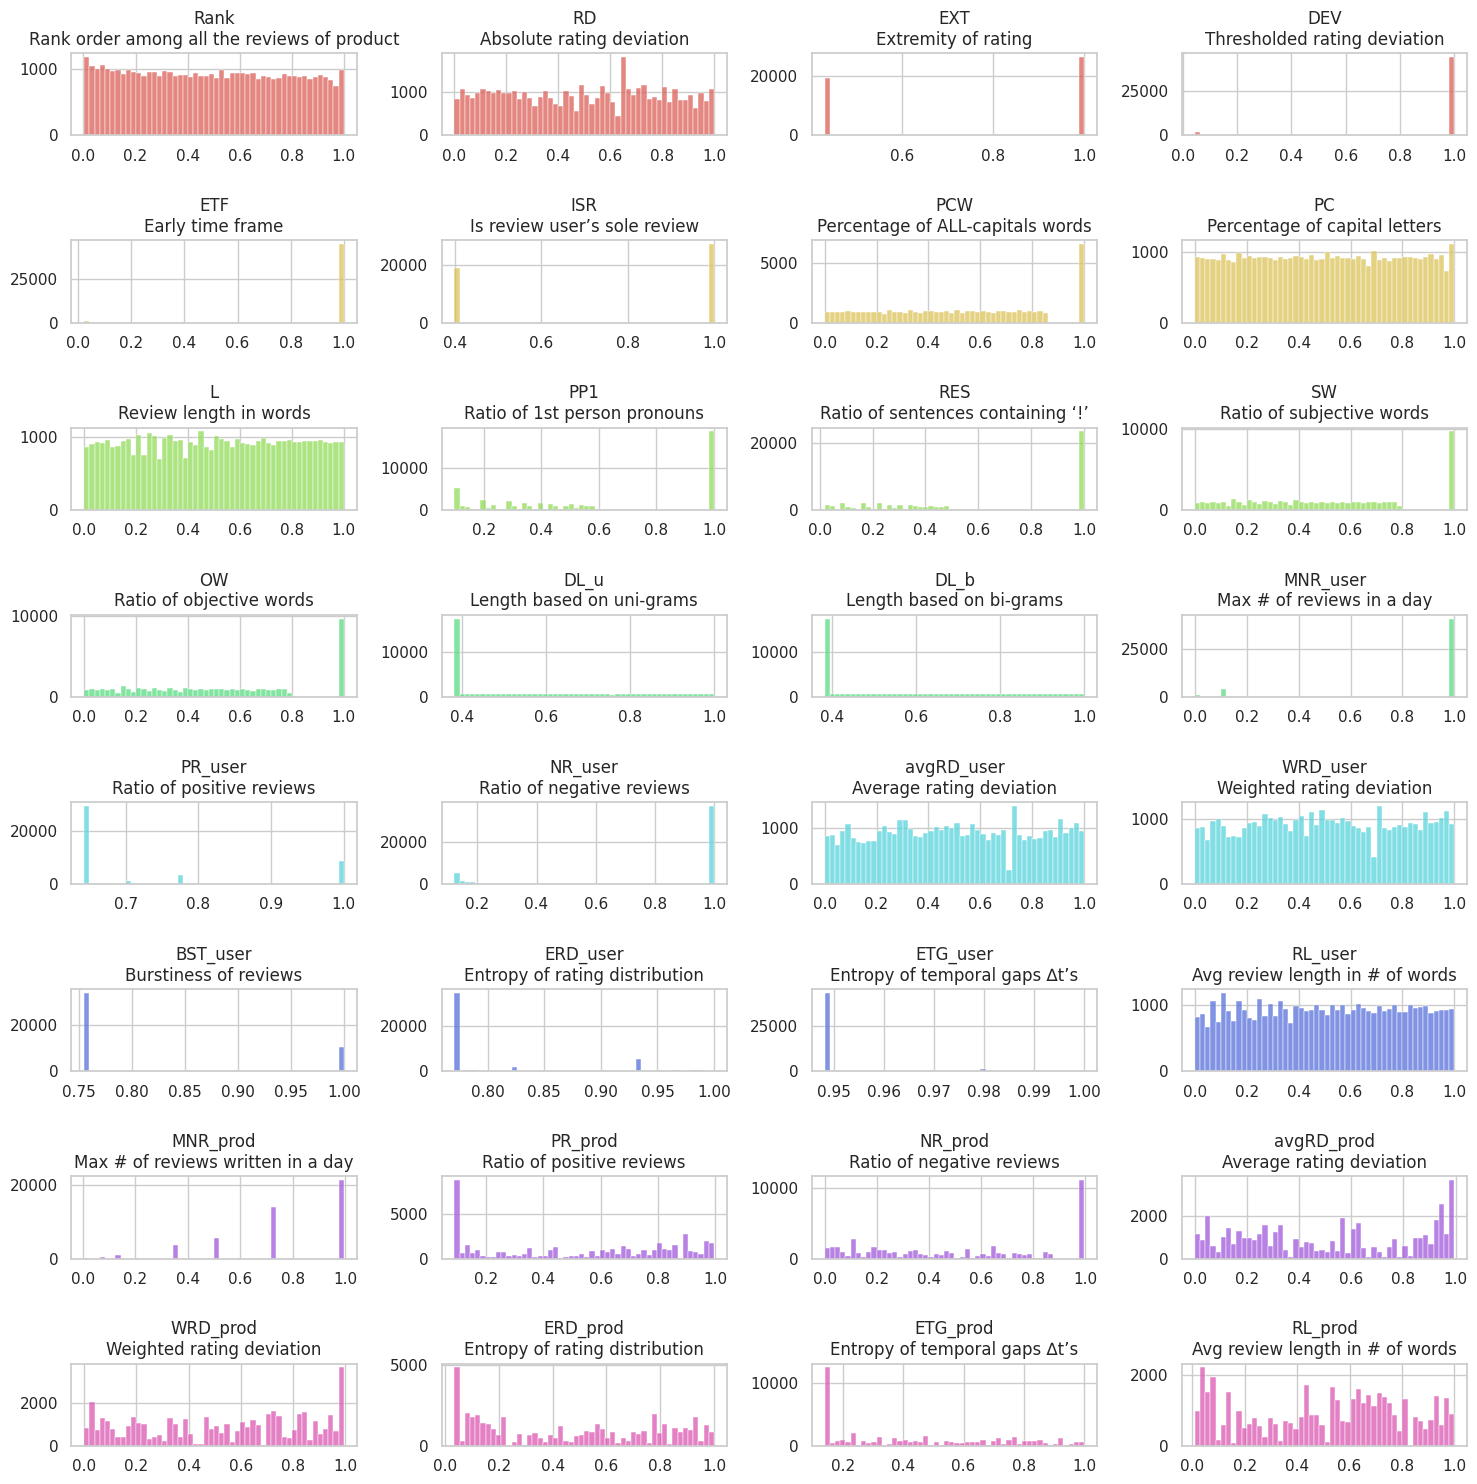

In [22]:
import seaborn as sns
sns.set(style="whitegrid")

fig, ax = plt.subplots(8, 4, figsize=(15, 15))
colors = sns.color_palette("hls", 8)
for i in range(8):
    for j in range(4):
        sns.histplot(features[:, 4*i+j], bins=50, ax=ax[i, j], color=colors[i])
        ax[i, j].set(xlabel='', ylabel='')
        ax[i, j].set_title(feature_names_short_desc_all[4*i+j])
plt.tight_layout(h_pad=2.0)


Distribution plots of Review-based features.

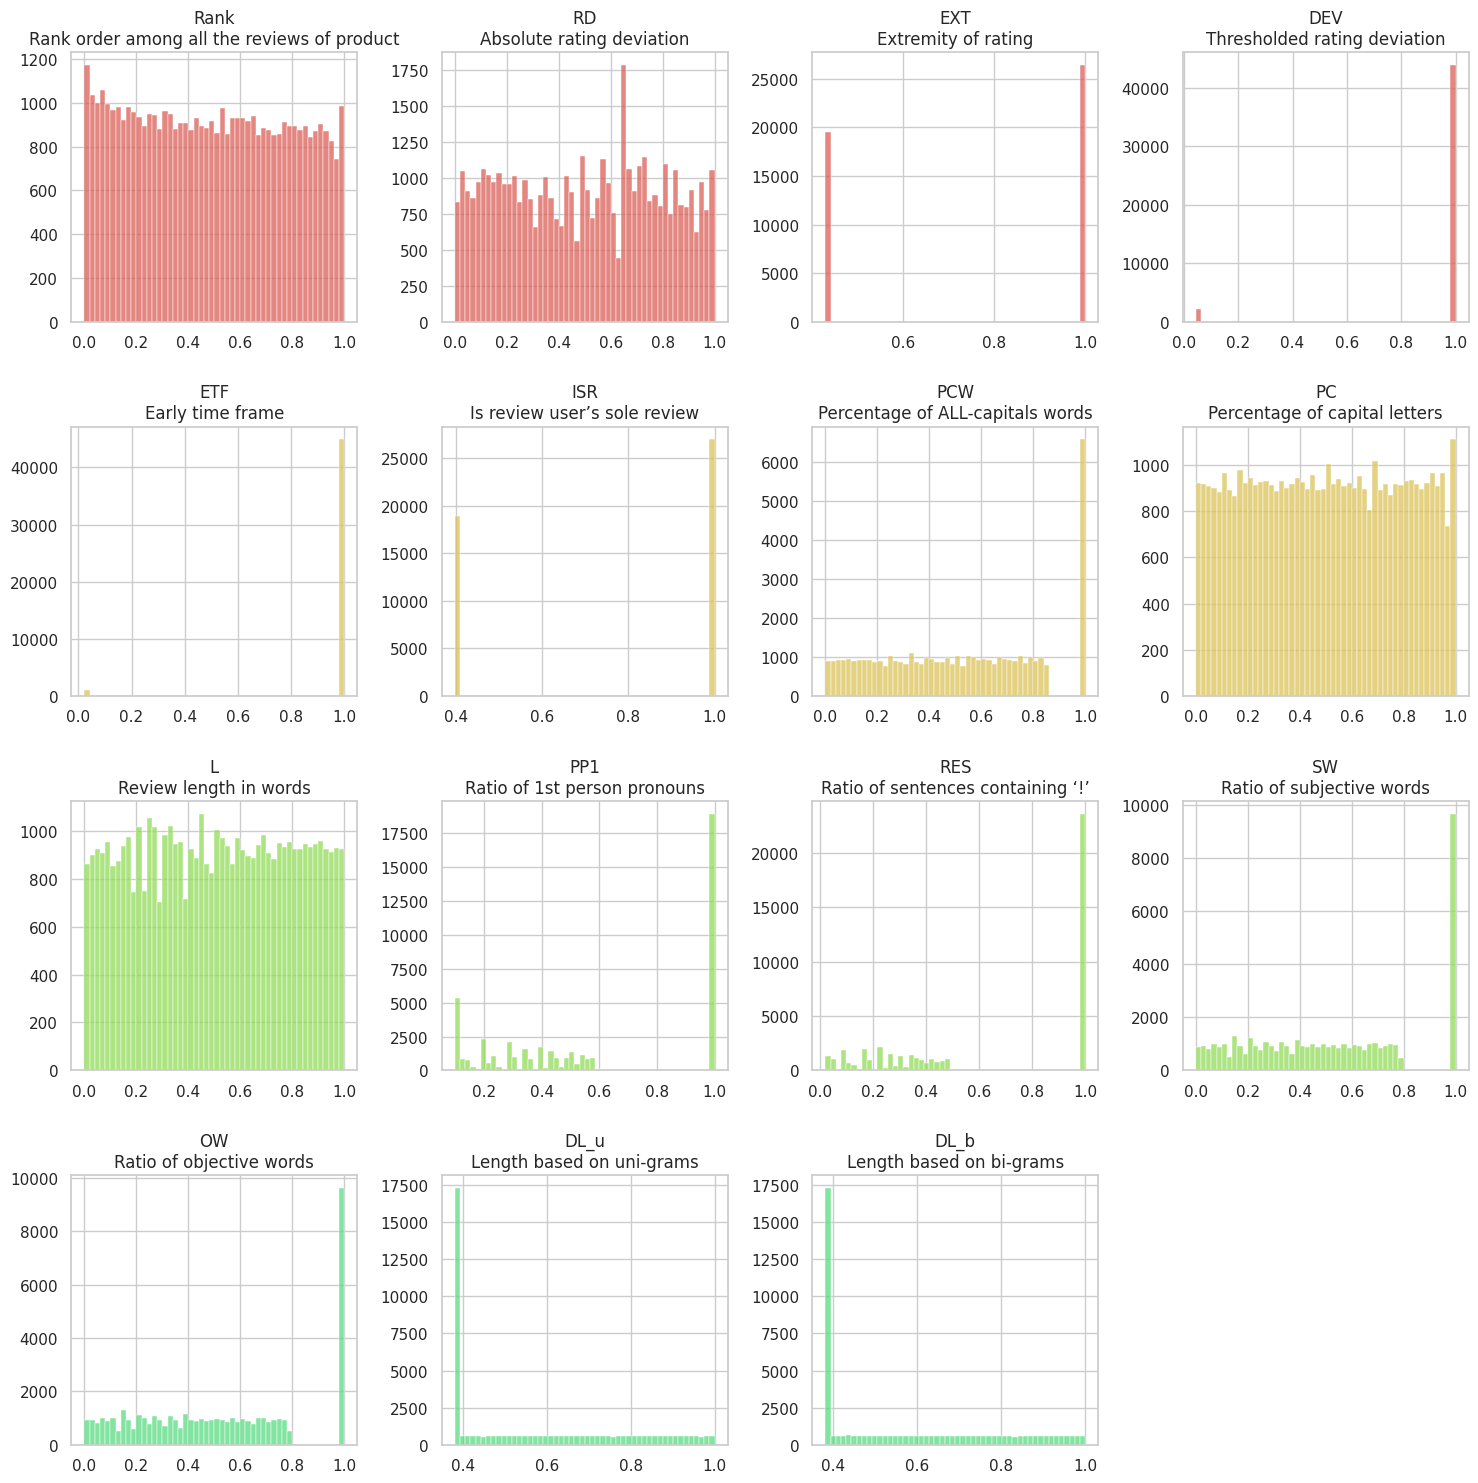

In [23]:
fig, ax = plt.subplots(4, 4, figsize=(15, 15))
colors = sns.color_palette("hls", 8)
for i in range(4):
    for j in range(4):
        if i==3 and j > 2:
            ax[i, j].remove()
            continue
        sns.histplot(features[:, 4*i+j], bins=50, ax=ax[i, j], color=colors[i], stat='count')
        ax[i, j].set(xlabel='', ylabel='')
        ax[i, j].set_title(feature_names_short_desc_review[4*i+j])
plt.tight_layout(h_pad=2.0)

Distribution plots of User-based features.

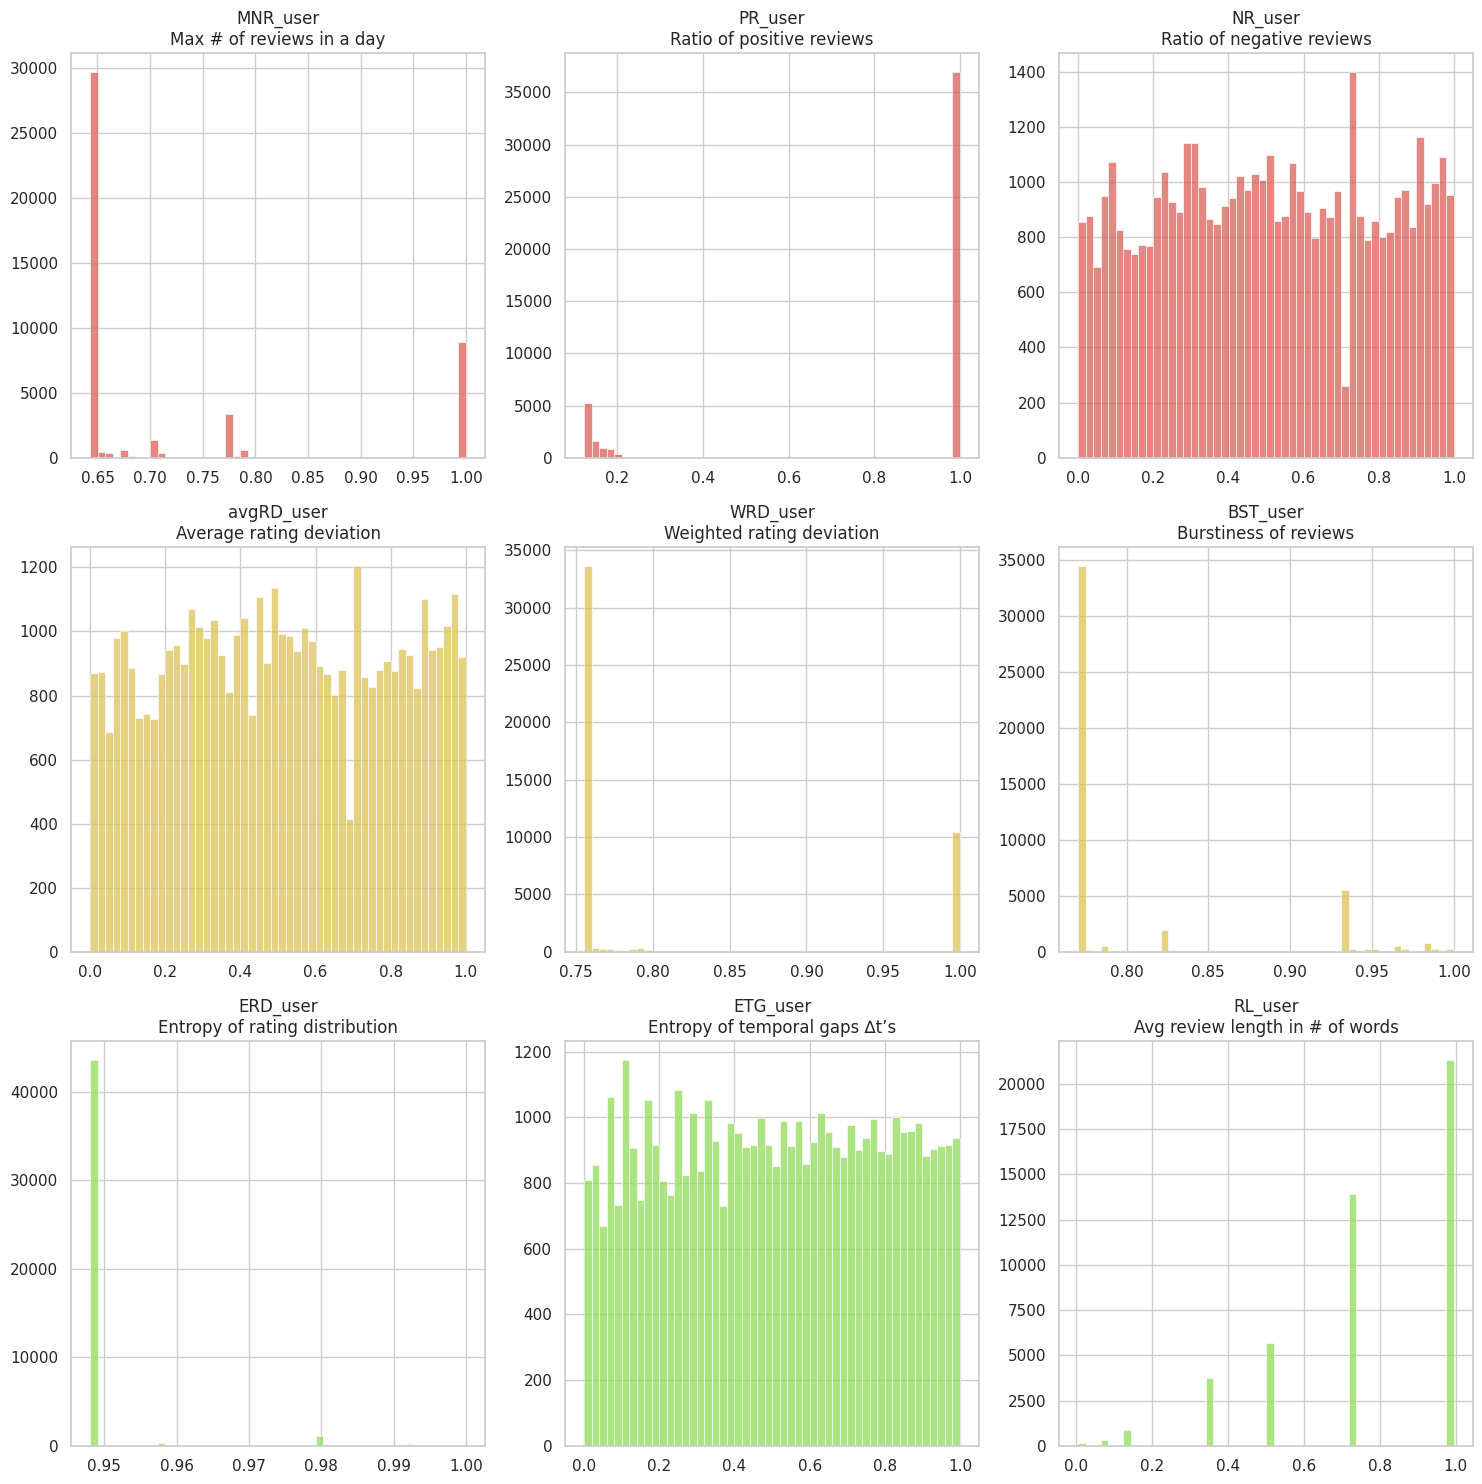

In [24]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))
colors = sns.color_palette("hls", 8)
cnt=15
for i in range(3):
    for j in range(3):
        cnt+=1
        sns.histplot(features[:, cnt], bins=50, ax=ax[i, j], color=colors[i], stat='count')
        # sns.displot(features[:, cnt], bins=50, ax=ax[i, j], color=colors[i], )
        ax[i, j].set(xlabel='', ylabel='')
        ax[i, j].set_title(feature_names_short_desc_user[3*i+j])
plt.tight_layout()

Distribution plots of Product-based features.

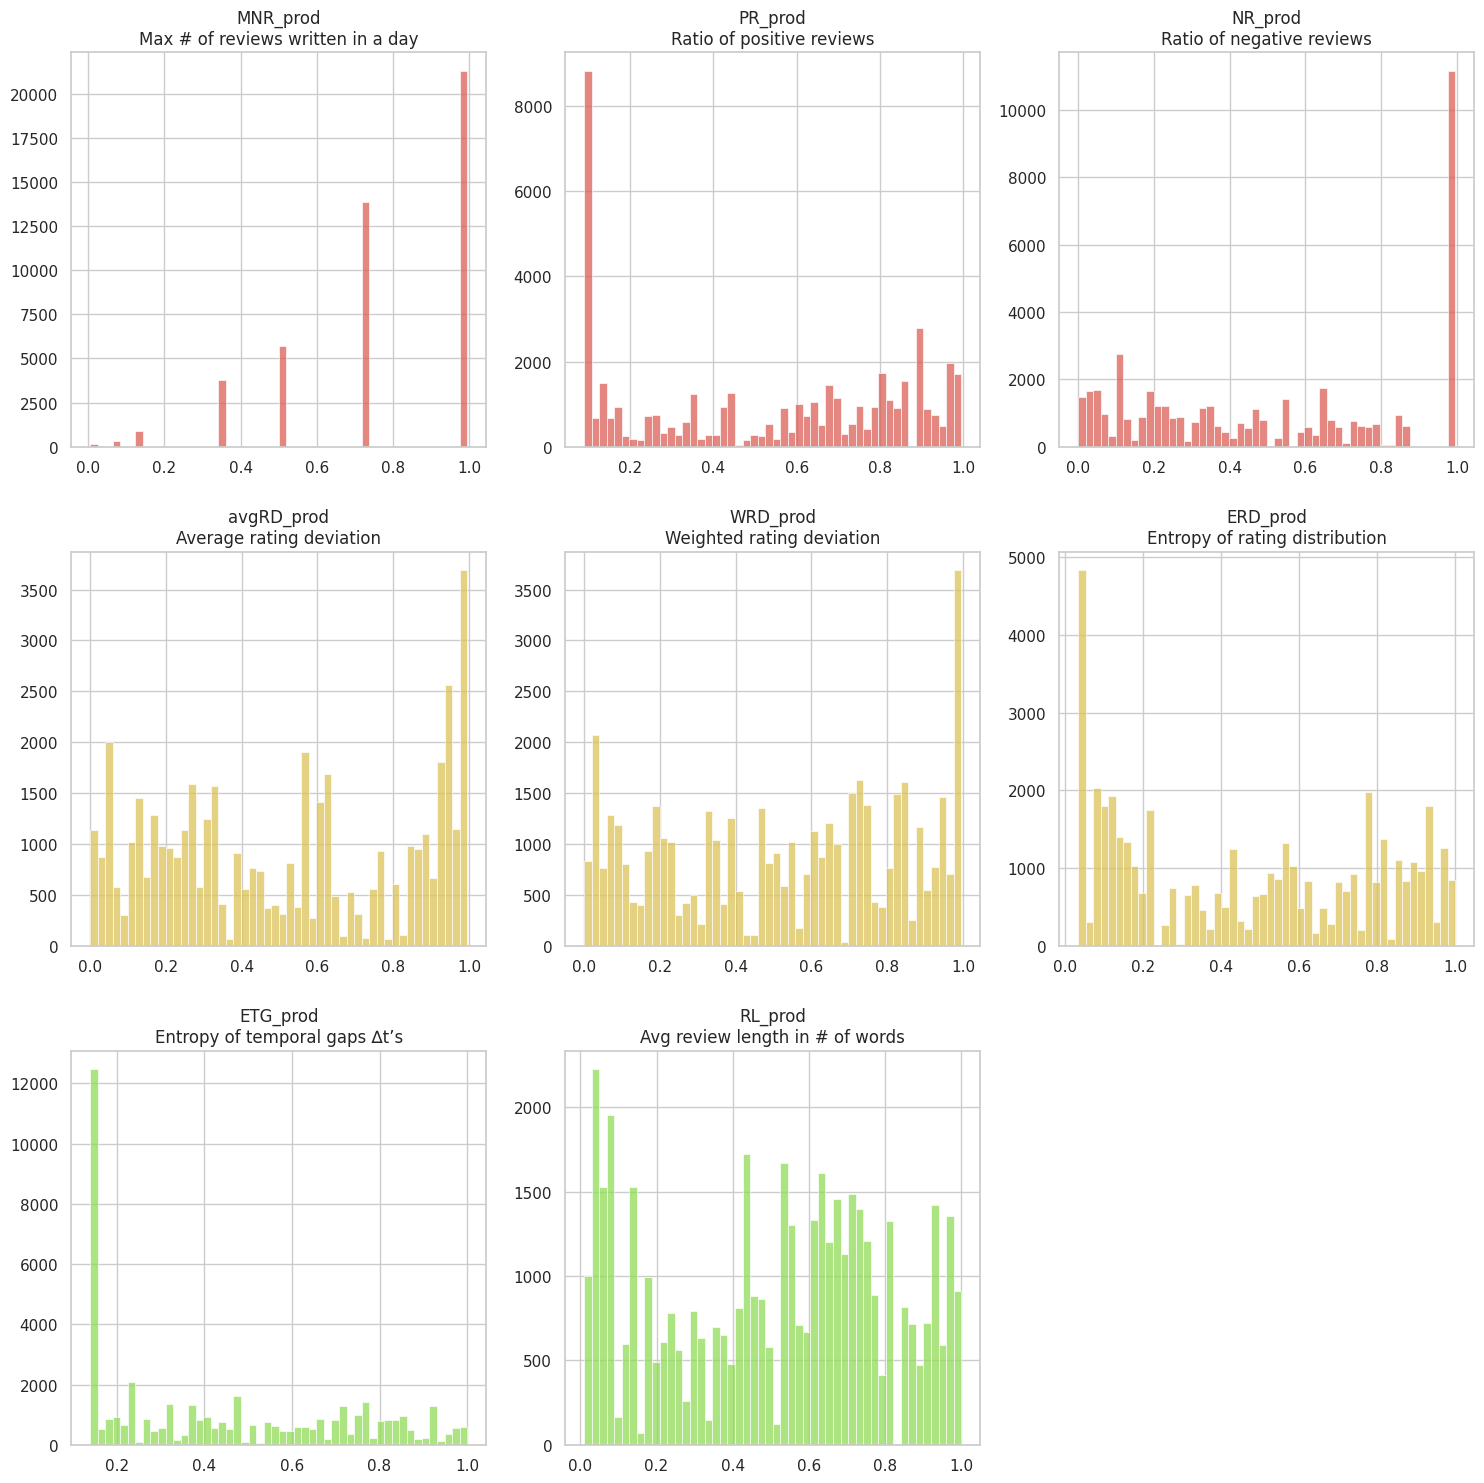

In [25]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))
colors = sns.color_palette("hls", 8)
cnt = 23
for i in range(3):
    for j in range(3):
        cnt+=1
        if i==2 and j > 1:
            ax[i, j].remove()
            continue
        sns.histplot(features[:, cnt],  bins=50, ax=ax[i, j], color=colors[i], stat='count')
        ax[i, j].set(xlabel='', ylabel='')
        ax[i, j].set_title(feature_names_short_desc_product[3*i+j])
plt.tight_layout(h_pad=2.0)

----
Convert the numpy array of features into a pandas dataframe. Apply a pairplot to the features (optional, as this will take a while).

In [26]:
type(features)

numpy.ndarray

In [27]:
features_df = pd.DataFrame(features, columns=feature_names)

In [28]:
features_df.head()

,Rank,RD,EXT,DEV,ETF,ISR,PCW,PC,L,PP1,...,ETG_user,RL_user,MNR_prod,PR_prod,NR_prod,avgRD_prod,WRD_prod,ERD_prod,ETG_prod,RL_prod
0,0.022376,0.070495,0.428682,0.999985,0.999985,0.398457,0.823592,0.497025,0.965457,0.150263,...,0.94806,0.867772,0.995025,0.910448,0.079602,0.00995,0.014925,0.59204,0.139303,0.497512
1,0.024928,0.999985,0.999985,0.999985,0.999985,0.398457,0.999985,0.941257,0.217850,0.098019,...,0.94806,0.826367,0.995025,0.910448,0.079602,0.00995,0.014925,0.59204,0.139303,0.497512
2,0.006173,0.070495,0.428682,0.999985,0.999985,0.398457,0.057230,0.151243,0.841056,1.000000,...,0.94806,0.802564,0.995025,0.910448,0.079602,0.00995,0.014925,0.59204,0.139303,0.497512
3,0.017375,0.070495,0.428682,0.999985,0.999985,0.398457,0.999985,0.930203,0.025402,0.098019,...,0.94806,0.387121,0.995025,0.910448,0.079602,0.00995,0.014925,0.59204,0.139303,0.497512
4,0.009081,0.999985,0.999985,0.999985,0.999985,0.398457,0.159374,0.697188,0.195489,1.000000,...,0.94806,0.246985,0.995025,0.910448,0.079602,0.00995,0.014925,0.59204,0.139303,0.497512


In [29]:
df_normalized = pd.DataFrame(
    normalize(features_df, norm='l1', axis=1),
    columns=features_df.columns,
    index=features_df.index
)

In [30]:
df_normalized

,Rank,RD,EXT,DEV,ETF,ISR,PCW,PC,L,PP1,...,ETG_user,RL_user,MNR_prod,PR_prod,NR_prod,avgRD_prod,WRD_prod,ERD_prod,ETG_prod,RL_prod
0,0.001172,0.003692,0.022449,0.052367,0.052367,0.020866,0.043130,0.026028,0.050559,0.007869,...,0.049648,0.045443,0.052107,0.047678,0.004169,0.000521,0.000782,0.031004,0.007295,0.026054
1,0.001255,0.050355,0.050355,0.050355,0.050355,0.020065,0.050355,0.047398,0.010970,0.004936,...,0.047740,0.041612,0.050105,0.045846,0.004008,0.000501,0.000752,0.029813,0.007015,0.025053
2,0.000346,0.003956,0.024057,0.056119,0.056119,0.022361,0.003212,0.008488,0.047200,0.056119,...,0.053204,0.045039,0.055840,0.051094,0.004467,0.000558,0.000838,0.033225,0.007818,0.027920
3,0.000898,0.003644,0.022161,0.051695,0.051695,0.020599,0.051695,0.048088,0.001313,0.005067,...,0.049011,0.020013,0.051439,0.047067,0.004115,0.000514,0.000772,0.030606,0.007201,0.025719
4,0.000510,0.056152,0.056152,0.056152,0.056152,0.022374,0.008949,0.039149,0.010977,0.056153,...,0.053236,0.013869,0.055873,0.051124,0.004470,0.000559,0.000838,0.033245,0.007822,0.027937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45949,0.000466,0.035691,0.022013,0.051349,0.051349,0.051349,0.000731,0.006136,0.017889,0.051349,...,0.048682,0.025091,0.003321,0.014562,0.028613,0.023503,0.013795,0.018905,0.015584,0.043430
45950,0.000186,0.033586,0.058519,0.058519,0.001334,0.023318,0.058519,0.029281,0.013081,0.005736,...,0.055480,0.023598,0.020671,0.019216,0.029697,0.035228,0.023583,0.028241,0.046874,0.009608
45951,0.000570,0.021975,0.026913,0.062781,0.062781,0.025016,0.062781,0.039049,0.007673,0.017599,...,0.059521,0.045928,0.022177,0.020615,0.031859,0.037794,0.025300,0.030298,0.050288,0.010307
45952,0.000321,0.003669,0.052044,0.052044,0.052044,0.052044,0.005036,0.015513,0.027595,0.052045,...,0.049342,0.037774,0.006473,0.021232,0.036250,0.040652,0.044536,0.023045,0.023304,0.030554


In [31]:
features_df = df_normalized.copy()

In [32]:
X_normalized = normalize(features, norm='l1', axis=1)



In [33]:
row_sums = np.sum(X_normalized, axis=1)
print(row_sums)

[1. 1. 1. ... 1. 1. 1.]


In [34]:
row_sums = np.sum(features, axis=1)
print(row_sums)

[19.09579298 19.85862704 17.8191696  ... 15.92821549 19.21404717
 15.87763779]


In [35]:
features = X_normalized.copy()

Optional pairplot commands. Commented out to avoid a long wait.)

In [36]:
# sns.pairplot(features_df.iloc[:, :15])

In [37]:
# sns.pairplot(features_df.iloc[:, 15:23])

In [38]:
# sns.pairplot(features_df.iloc[:, 23:32])

###II. Data Preprocessing and **Training**

In [39]:
# split data into test and train
from sklearn.model_selection import train_test_split
split = 0.2
xtrain, xtest, ytrain, ytest = train_test_split(features, labels, test_size = split,
                                                                    stratify=labels,
                                                                    random_state = 99)


In [40]:
xtrain

array([[0.03405227, 0.03971673, 0.04598851, ..., 0.04324357, 0.03317628,
        0.03088826],
       [0.01438447, 0.00717129, 0.022413  , ..., 0.02757242, 0.0470812 ,
        0.01118504],
       [0.02298802, 0.04516371, 0.04623812, ..., 0.03657697, 0.02944561,
        0.04301819],
       ...,
       [0.02297978, 0.00043003, 0.0219503 , ..., 0.0048402 , 0.00713292,
        0.0275127 ],
       [0.04890487, 0.02176061, 0.02140644, ..., 0.04596055, 0.01093116,
        0.03006068],
       [0.00065938, 0.0169155 , 0.04488731, ..., 0.00156326, 0.00625305,
        0.0037965 ]])

In [41]:
from collections import Counter

def check_balance(labels):
    counter = Counter(labels)
    for k, v in counter.items():
        per = v / len(labels) * 100
        print('Class=%d, n=%d (%.3f%%)' % (k, v, per))

# assuming 'y' is your labels
check_balance(ytrain)

Class=1, n=5342 (14.531%)
Class=0, n=31421 (85.469%)


In [42]:
print(ytrain.sum()/len(ytrain))
print(ytest.sum()/len(ytest))


0.14530914234420478
0.14525078881514525


In [43]:
#double check shapes
print(f'Required shape is {int(len(features)*(1-split))}')
print(f'xtrain shape = {xtrain.shape}, xtest shape = {xtest.shape}')
print(f'Correct split = {int(len(features)*(1-split)) == xtrain.shape[0]}')

Required shape is 36763
xtrain shape = (36763, 32), xtest shape = (9191, 32)
Correct split = True


####Logistic Regression

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, log_loss

# Fit the logistic regression model
clf = LogisticRegression(random_state=0).fit(xtrain, ytrain)

# Predict probabilities
ypred_proba = clf.predict_proba(xtest)[:, 1]

# Convert probabilities to binary labels
ypred_binary = (ypred_proba > 0.5).astype(int)

# Calculate ROC AUC score
roc_auc = roc_auc_score(ytest, ypred_proba)

# Calculate F1-score, Precision, and Recall
f1 = f1_score(ytest, ypred_binary)
precision = precision_score(ytest, ypred_binary)
recall = recall_score(ytest, ypred_binary)

# Calculate Log Loss
logloss = log_loss(ytest, ypred_proba)

print(f"Model ROC AUC (logistic regression) = {100 * roc_auc:.2f}%")
print(f"Model F1-score (logistic regression) = {f1:.3f}")
print(f"Model Precision (logistic regression) = {precision:.3f}")
print(f"Model Recall (logistic regression) = {recall:.3f}")
print(f"Model Log Loss (logistic regression) = {logloss:.3f}")


Model ROC AUC (logistic regression) = 74.40%
Model F1-score (logistic regression) = 0.001
Model Precision (logistic regression) = 0.500
Model Recall (logistic regression) = 0.001
Model Log Loss (logistic regression) = 0.373


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, log_loss

# Fit the logistic regression model
clf = LogisticRegression(random_state=0).fit(xtrain, ytrain)

# Predict probabilities
ypred_proba = clf.predict_proba(xtest)[:, 1]

# Convert probabilities to binary labels
ypred_binary = (ypred_proba > 0.5).astype(int)

# Calculate ROC AUC score
roc_auc = roc_auc_score(ytest, ypred_proba)

# Calculate F1-score, Precision, and Recall
f1 = f1_score(ytest, ypred_binary)
precision = precision_score(ytest, ypred_binary)
recall = recall_score(ytest, ypred_binary)

# Calculate Log Loss
logloss = log_loss(ytest, ypred_proba)

print(f"Model ROC AUC (logistic regression) = {100 * roc_auc:.2f}%")
print(f"Model F1-score (logistic regression) = {f1:.3f}")
print(f"Model Precision (logistic regression) = {precision:.3f}")
print(f"Model Recall (logistic regression) = {recall:.3f}")
print(f"Model Log Loss (logistic regression) = {logloss:.3f}")


Model ROC AUC (logistic regression) = 74.40%
Model F1-score (logistic regression) = 0.001
Model Precision (logistic regression) = 0.500
Model Recall (logistic regression) = 0.001
Model Log Loss (logistic regression) = 0.373


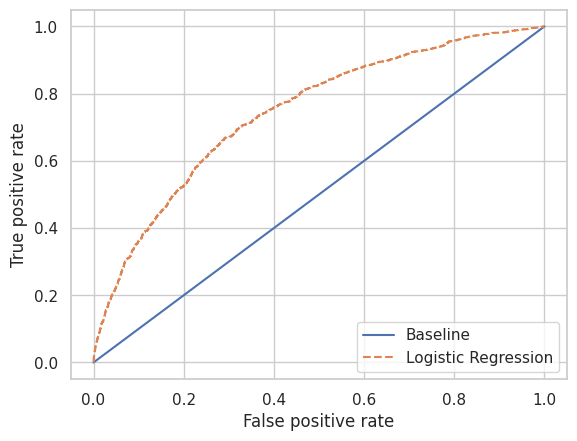

In [46]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(ytest,ypred_proba)

plt.figure(1)
plt.plot([0, 1], [0, 1], linestyle='-', label='Baseline')
plt.plot(fpr, tpr, linestyle='--', label='Logistic Regression')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc='lower right')

plt.show()

####XGBoost

In [47]:
# ## Apply XGBoost for second baseline
import xgboost as xgb
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
xgb_classifier = xgb.XGBClassifier()

In [48]:
# Initialize and fit the XGBoost classifier
xgb_classifier = XGBClassifier()
xgb_classifier.fit(xtrain, ytrain)

# Predict probabilities for the test set
ypred_proba = xgb_classifier.predict_proba(xtest)[:, 1]

# Convert probabilities to binary labels based on a threshold (0.5 used here)
ypred_binary = (ypred_proba > 0.5).astype(int)

# Calculate the ROC AUC score
roc_auc = roc_auc_score(ytest, ypred_proba)

# Calculate F1-score, Precision, and Recall
f1 = f1_score(ytest, ypred_binary)
precision = precision_score(ytest, ypred_binary)
recall = recall_score(ytest, ypred_binary)

# Calculate Log Loss
logloss = log_loss(ytest, ypred_proba)


# Print the scores
print(f"Model ROC AUC (XGBoost) = {100 * roc_auc:.2f}%")
print(f"Model F1-score (XGBoost) = {f1:.3f}")
print(f"Model Precision (XGBoost) = {precision:.3f}")
print(f"Model Recall (XGBoost) = {recall:.3f}")
print(f"Model Log Loss (XGBoost) = {logloss:.3f}")


Model ROC AUC (XGBoost) = 88.19%
Model F1-score (XGBoost) = 0.549
Model Precision (XGBoost) = 0.702
Model Recall (XGBoost) = 0.451
Model Log Loss (XGBoost) = 0.272


In [49]:
# Initialize and fit the XGBoost classifier
xgb_classifier = XGBClassifier()
xgb_classifier.fit(xtrain, ytrain)

# Predict probabilities for the test set
ypred_proba = xgb_classifier.predict_proba(xtest)[:, 1]

# Convert probabilities to binary labels based on a threshold (0.5 used here)
ypred_binary = (ypred_proba > 0.5).astype(int)

# Calculate the ROC AUC score
roc_auc = roc_auc_score(ytest, ypred_proba)

# Calculate F1-score, Precision, and Recall
f1 = f1_score(ytest, ypred_binary)
precision = precision_score(ytest, ypred_binary)
recall = recall_score(ytest, ypred_binary)

# Calculate Log Loss
logloss = log_loss(ytest, ypred_proba)


# Print the scores
print(f"Model ROC AUC (XGBoost) = {100 * roc_auc:.2f}%")
print(f"Model F1-score (XGBoost) = {f1:.3f}")
print(f"Model Precision (XGBoost) = {precision:.3f}")
print(f"Model Recall (XGBoost) = {recall:.3f}")
print(f"Model Log Loss (XGBoost) = {logloss:.3f}")


Model ROC AUC (XGBoost) = 88.19%
Model F1-score (XGBoost) = 0.549
Model Precision (XGBoost) = 0.702
Model Recall (XGBoost) = 0.451
Model Log Loss (XGBoost) = 0.272


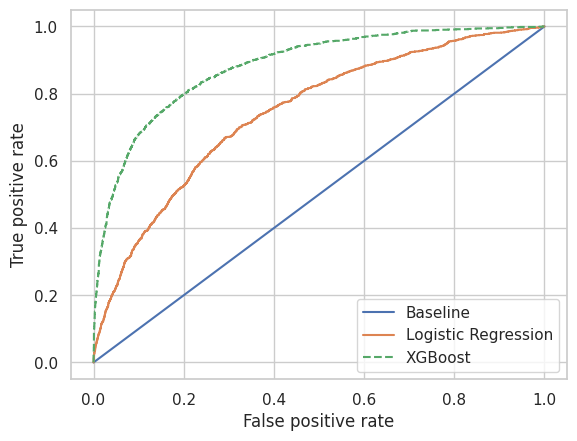

In [50]:
fpr2, tpr2, _ = roc_curve(ytest,ypred_proba)

plt.figure(1)
plt.plot([0, 1], [0, 1], label='Baseline')
plt.plot(fpr, tpr, linestyle='-', label='Logistic Regression')
plt.plot(fpr2, tpr2, linestyle='--', label='XGBoost')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc='lower right')

plt.show()

####MLP

In [51]:
# Apply MLP for third baseline

import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        layers = []
        layers.append(nn.Linear(32, 30)) # First layer
        layers.append(nn.ReLU()) # Activation function
        layers.append(nn.Dropout(0.5)) # Dropout layer

        for i in range(20): # 20 hidden layers
            layers.append(nn.Linear(30, 30)) # Add a linear layer
            layers.append(nn.ReLU()) # Add activation function
            layers.append(nn.Dropout(0.5)) # Dropout layer

        layers.append(nn.Linear(30, 50)) # Another linear layer
        layers.append(nn.ReLU()) # Activation function
        layers.append(nn.Dropout(0.5)) # Dropout layer
        layers.append(nn.Linear(50, 1)) # Final layer
        layers.append(nn.Sigmoid()) # Activation function

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        x = self.layers(x)
        return x.view(-1, 1)

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Assume xtrain, ytrain, xtest, and ytest are already defined and preprocessed
# Their shapes should be: xtrain(62842, 32), xtest(9191, 32)

# Convert data to PyTorch tensors
xtrain = torch.FloatTensor(xtrain)
ytrain = torch.LongTensor(ytrain)
xtest = torch.FloatTensor(xtest)
ytest = torch.LongTensor(ytest)

# Define the MLP model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(32, 64),  # Input size is 32 to match the number of features
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.layers(x)

# Initialize model, criterion, and optimizer
model = MLP()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
epochs = 10000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    output = model(xtrain).squeeze()
    loss = criterion(output, ytrain.float())
    loss.backward()
    optimizer.step()

    # Evaluation
    with torch.no_grad():
        model.eval()
        test_output = model(xtest).squeeze()
        test_prob = torch.sigmoid(test_output)
        ypred_proba = test_prob.numpy()
        ypred_binary = (ypred_proba > 0.5).astype(int)

        roc_auc = roc_auc_score(ytest, ypred_proba)
        f1 = f1_score(ytest, ypred_binary)
        precision = precision_score(ytest, ypred_binary)
        recall = recall_score(ytest, ypred_binary)
        logloss = log_loss(ytest.numpy(), ypred_proba)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Loss: {loss.item():.4f} | "
          f"ROC AUC: {roc_auc:.3f} | "
          f"F1-score: {f1:.3f} | "
          f"Precision: {precision:.3f} | "
          f"Recall: {recall:.3f} | "
          f"Log Loss: {logloss:.3f}")

Epoch 1/10000 | Loss: 0.7174 | ROC AUC: 0.508 | F1-score: 0.254 | Precision: 0.145 | Recall: 1.000 | Log Loss: 0.715
Epoch 2/10000 | Loss: 0.7147 | ROC AUC: 0.505 | F1-score: 0.254 | Precision: 0.145 | Recall: 1.000 | Log Loss: 0.712
Epoch 3/10000 | Loss: 0.7119 | ROC AUC: 0.503 | F1-score: 0.254 | Precision: 0.145 | Recall: 1.000 | Log Loss: 0.709
Epoch 4/10000 | Loss: 0.7091 | ROC AUC: 0.501 | F1-score: 0.254 | Precision: 0.145 | Recall: 1.000 | Log Loss: 0.706
Epoch 5/10000 | Loss: 0.7064 | ROC AUC: 0.499 | F1-score: 0.254 | Precision: 0.145 | Recall: 1.000 | Log Loss: 0.704
Epoch 6/10000 | Loss: 0.7036 | ROC AUC: 0.498 | F1-score: 0.254 | Precision: 0.145 | Recall: 1.000 | Log Loss: 0.701
Epoch 7/10000 | Loss: 0.7008 | ROC AUC: 0.498 | F1-score: 0.254 | Precision: 0.145 | Recall: 1.000 | Log Loss: 0.698
Epoch 8/10000 | Loss: 0.6981 | ROC AUC: 0.498 | F1-score: 0.255 | Precision: 0.147 | Recall: 0.985 | Log Loss: 0.695
Epoch 9/10000 | Loss: 0.6953 | ROC AUC: 0.498 | F1-score: 0.181 

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.p

Epoch 17/10000 | Loss: 0.6732 | ROC AUC: 0.506 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.670
Epoch 18/10000 | Loss: 0.6704 | ROC AUC: 0.508 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.668
Epoch 19/10000 | Loss: 0.6676 | ROC AUC: 0.510 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.665
Epoch 20/10000 | Loss: 0.6648 | ROC AUC: 0.511 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.662
Epoch 21/10000 | Loss: 0.6620 | ROC AUC: 0.513 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.659
Epoch 22/10000 | Loss: 0.6591 | ROC AUC: 0.515 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.656
Epoch 23/10000 | Loss: 0.6563 | ROC AUC: 0.516 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.653
Epoch 24/10000 | Loss: 0.6535 | ROC AUC: 0.517 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.651


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.p

Epoch 25/10000 | Loss: 0.6506 | ROC AUC: 0.518 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.648
Epoch 26/10000 | Loss: 0.6477 | ROC AUC: 0.518 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.645
Epoch 27/10000 | Loss: 0.6449 | ROC AUC: 0.517 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.642
Epoch 28/10000 | Loss: 0.6420 | ROC AUC: 0.517 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.639
Epoch 29/10000 | Loss: 0.6391 | ROC AUC: 0.517 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.636
Epoch 30/10000 | Loss: 0.6363 | ROC AUC: 0.516 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.633
Epoch 31/10000 | Loss: 0.6334 | ROC AUC: 0.516 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.631
Epoch 32/10000 | Loss: 0.6306 | ROC AUC: 0.515 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.628


...

Epoch 873/10000 | Loss: 0.3831 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 874/10000 | Loss: 0.3830 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 875/10000 | Loss: 0.3830 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 876/10000 | Loss: 0.3829 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 877/10000 | Loss: 0.3829 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 878/10000 | Loss: 0.3828 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 879/10000 | Loss: 0.3828 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 880/10000 | Loss: 0.3828 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.p

Epoch 881/10000 | Loss: 0.3827 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 882/10000 | Loss: 0.3827 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 883/10000 | Loss: 0.3826 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 884/10000 | Loss: 0.3826 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 885/10000 | Loss: 0.3825 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 886/10000 | Loss: 0.3825 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 887/10000 | Loss: 0.3825 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.385
Epoch 888/10000 | Loss: 0.3824 | ROC AUC: 0.718 | F1-score: 0.000 | Precision: 0.000 | Recall: 0.000 | Log Loss: 0.384


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.p

Streaming output truncated to the last 5000 lines.
Epoch 5001/10000 | Loss: 0.3405 | ROC AUC: 0.775 | F1-score: 0.246 | Precision: 0.611 | Recall: 0.154 | Log Loss: 0.349
Epoch 5002/10000 | Loss: 0.3405 | ROC AUC: 0.775 | F1-score: 0.246 | Precision: 0.611 | Recall: 0.154 | Log Loss: 0.349
Epoch 5003/10000 | Loss: 0.3405 | ROC AUC: 0.775 | F1-score: 0.246 | Precision: 0.611 | Recall: 0.154 | Log Loss: 0.349
Epoch 5004/10000 | Loss: 0.3405 | ROC AUC: 0.775 | F1-score: 0.246 | Precision: 0.611 | Recall: 0.154 | Log Loss: 0.349
Epoch 5005/10000 | Loss: 0.3405 | ROC AUC: 0.775 | F1-score: 0.246 | Precision: 0.611 | Recall: 0.154 | Log Loss: 0.349
Epoch 5006/10000 | Loss: 0.3405 | ROC AUC: 0.775 | F1-score: 0.246 | Precision: 0.611 | Recall: 0.154 | Log Loss: 0.349
Epoch 5007/10000 | Loss: 0.3405 | ROC AUC: 0.775 | F1-score: 0.246 | Precision: 0.611 | Recall: 0.154 | Log Loss: 0.349
Epoch 5008/10000 | Loss: 0.3405 | ROC AUC: 0.775 | F1-score: 0.246 | Precision: 0.611 | Recall: 0.154 | Log L

In [53]:
# Final evaluation
with torch.no_grad():
    model.eval()
    test_output = model(xtest).squeeze()
    test_prob = torch.sigmoid(test_output)
    ypred_proba = test_prob.numpy()
    ypred_binary = (ypred_proba > 0.5).astype(int)

    roc_auc = roc_auc_score(ytest.numpy(), ypred_proba)
    f1 = f1_score(ytest.numpy(), ypred_binary)
    precision = precision_score(ytest.numpy(), ypred_binary)
    recall = recall_score(ytest.numpy(), ypred_binary)
    logloss = log_loss(ytest.numpy(), ypred_proba)

    print("\nFinal Evaluation Results:")
    print(f"Model ROC AUC (MLP) = {100 * roc_auc:.2f}%")
    print(f"Model F1-score (MLP) = {f1:.3f}")
    print(f"Model Precision (MLP) = {precision:.3f}")
    print(f"Model Recall (MLP) = {recall:.3f}")
    print(f"Model Log Loss (MLP) = {logloss:.3f}")


Final Evaluation Results:
Model ROC AUC (MLP) = 80.64%
Model F1-score (MLP) = 0.359
Model Precision (MLP) = 0.639
Model Recall (MLP) = 0.249
Model Log Loss (MLP) = 0.330


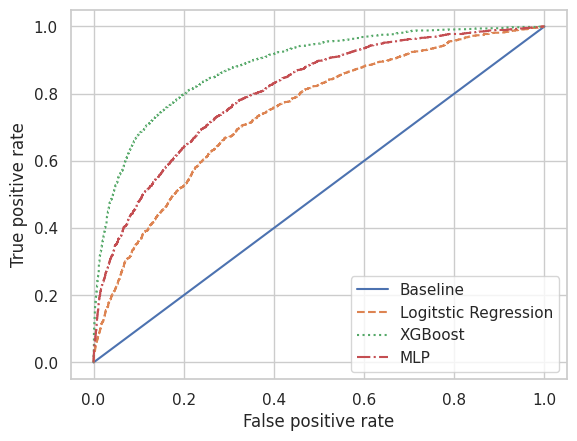

In [54]:
fpr3, tpr3, _ = roc_curve(ytest,ypred_proba)


plt.figure(1)
plt.plot([0, 1], [0, 1], linestyle='-', label='Baseline')  # Use a solid line for the baseline
plt.plot(fpr, tpr, linestyle='--', label='Logitstic Regression')  # Use a dashed line for Model 1
plt.plot(fpr2, tpr2, linestyle=':', label='XGBoost')  # Use a dotted line for Model 2
plt.plot(fpr3, tpr3, linestyle='-.', label='MLP')  # Use a dash-dot line for Model 3
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc='lower right')
plt.show()